In [1]:
import importlib
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

axis2_dir = PROJECT_ROOT / 'notebooks' / '03_Topic_and_Insights'
if str(axis2_dir) not in sys.path:
    sys.path.append(str(axis2_dir))

from Data_preprocessing import Parameters_Path as config
importlib.reload(config)

INPUT_PATH   = PROJECT_ROOT / 'data' / 'processed' / 'preprocessed_input.csv'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'Experiment_3_LSI'
LDA_RESULTS  = PROJECT_ROOT / 'results' / 'Experiment_1_LDA'
NMF_RESULTS  = PROJECT_ROOT / 'results' / 'Experiment_2_NMF'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

tfidf_cfg = config.PARAMETERS['tfidf_vectorizer']
lsi_cfg   = config.PARAMETERS['nmf']

EVAL_N_TOPICS = [4, 6, 8, 10, 12, 16]
LAMBDA_COST   = 0.25
N_TOP_WORDS   = int(lsi_cfg['n_top_words'])
RANDOM_STATE  = int(lsi_cfg['random_state'])


In [3]:
df    = pd.read_csv(INPUT_PATH)
texts = df['text_cleaned_axis1'].astype(str).str.strip()
texts = texts[texts.ne('')]

vectorizer = TfidfVectorizer(
    max_df=tfidf_cfg['max_df'],
    min_df=tfidf_cfg['min_df'],
    max_features=tfidf_cfg['max_features'],
    stop_words=tfidf_cfg['stop_words']
)
X_tfidf       = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()
tokenized     = [t.split() for t in texts]
dictionary    = Dictionary(tokenized)

print('Corpus shape:', X_tfidf.shape)


Corpus shape: (8465, 1200)


## Grid Search

In [4]:
models, recon_errors = {}, {}
for k in EVAL_N_TOPICS:
    lsi = TruncatedSVD(
        n_components=k,
        random_state=RANDOM_STATE
    )
    lsi.fit(X_tfidf)
    models[k]       = lsi
    # Use 1 - explained variance as reconstruction error proxy
    recon_errors[k] = 1 - lsi.explained_variance_ratio_.sum()
    print(f'n_components={k}  reconstruction_err={recon_errors[k]:.4f}')

rows = []
for k, lsi in models.items():
    topic_words = [
        [feature_names[i] for i in topic.argsort()[-N_TOP_WORDS:][::-1]]
        for topic in lsi.components_
    ]
    coherence = CoherenceModel(
        topics=topic_words, texts=tokenized,
        dictionary=dictionary, coherence='c_v'
    ).get_coherence()
    rows.append({
        'n_topics': k,
        'coherence_cv': coherence,
        'recon_err': recon_errors[k]
    })

metrics_df = pd.DataFrame(rows)
print(metrics_df)


n_components=4  reconstruction_err=0.9313
n_components=6  reconstruction_err=0.8917
n_components=8  reconstruction_err=0.8546
n_components=10  reconstruction_err=0.8189
n_components=12  reconstruction_err=0.7868
n_components=16  reconstruction_err=0.7299
   n_topics  coherence_cv  recon_err
0         4      0.641914   0.931281
1         6      0.642729   0.891711
2         8      0.617639   0.854645
3        10      0.576515   0.818934
4        12      0.571901   0.786785
5        16      0.566753   0.729907


## Penalized Score

In [5]:
coh = metrics_df['coherence_cv']
k_  = metrics_df['n_topics']

metrics_df['coh_norm']  = (coh - coh.min()) / (coh.max() - coh.min() + 1e-8)
metrics_df['cost_norm'] = (k_  - k_.min())  / (k_.max()  - k_.min() + 1e-8)
metrics_df['penalized'] = metrics_df['coh_norm'] - LAMBDA_COST * metrics_df['cost_norm']

best_k = int(metrics_df.loc[metrics_df['penalized'].idxmax(), 'n_topics'])
print(f"Best n_components: {best_k}")

metrics_df.to_csv(RESULTS_DIR / 'Experiment_3_lsi_eval_metrics.csv', index=False)


Best n_components: 4


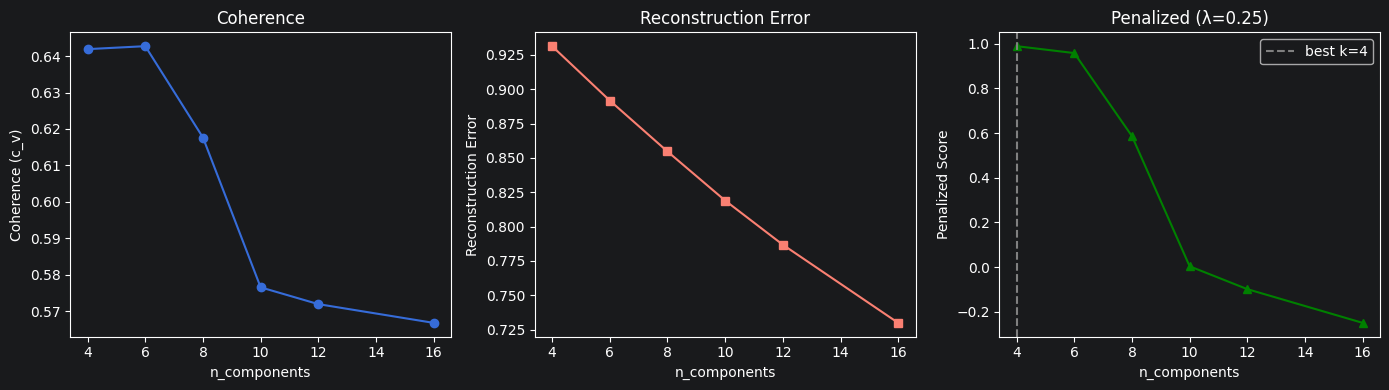

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(metrics_df['n_topics'], metrics_df['coherence_cv'], marker='o')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('Coherence (c_v)')
axes[0].set_title('Coherence')

axes[1].plot(metrics_df['n_topics'], metrics_df['recon_err'], marker='s', color='salmon')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Reconstruction Error')

axes[2].plot(metrics_df['n_topics'], metrics_df['penalized'], marker='^', color='green')
axes[2].axvline(best_k, linestyle='--', color='gray', label=f'best k={best_k}')
axes[2].set_xlabel('n_components')
axes[2].set_ylabel('Penalized Score')
axes[2].set_title(f'Penalized (λ={LAMBDA_COST})')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_3_lsi_eval_metrics.png')
plt.show()


## Confidence Distribution

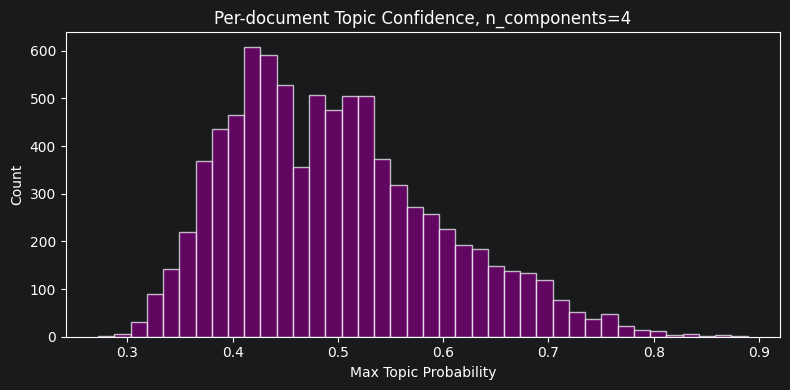

count    8465.000000
mean        0.496622
std         0.099363
min         0.272246
25%         0.420628
50%         0.485083
75%         0.557610
max         0.889077
Name: max_topic_prob, dtype: float64


In [7]:
doc_topic_df = pd.read_csv(RESULTS_DIR / 'Experiment_3_lsi_doc_topics.csv')

plt.figure(figsize=(8, 4))
plt.hist(doc_topic_df['max_topic_prob'], bins=40, color='purple', edgecolor='white', alpha=0.7)
plt.xlabel('Max Topic Probability')
plt.ylabel('Count')
plt.title(f'Per-document Topic Confidence, n_components={best_k}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_3_lsi_confidence_dist.png')
plt.show()

print(doc_topic_df['max_topic_prob'].describe())


## LSI vs LDA vs NMF Comparison

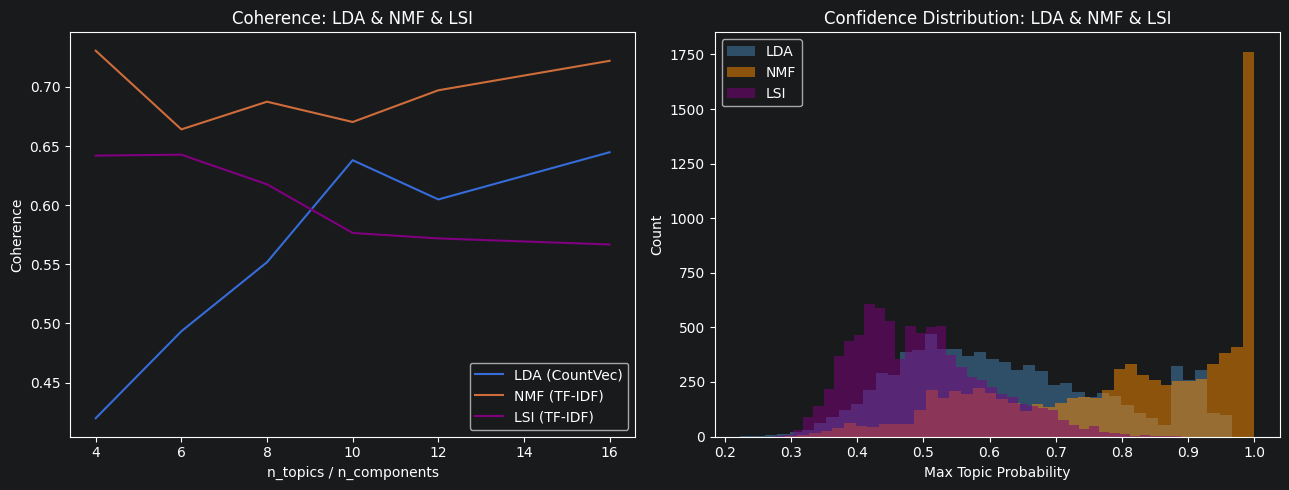

  Model  best_k  max_coherence  mean_confidence
0   LDA      10       0.644796         0.627165
1   NMF       4       0.730680         0.799784
2   LSI       4       0.642729         0.496622


In [8]:
lda_metrics = pd.read_csv(LDA_RESULTS / 'Experiment_1_lda_eval_metrics.csv')
nmf_metrics = pd.read_csv(NMF_RESULTS / 'Experiment_2_nmf_eval_metrics.csv')
lsi_metrics = metrics_df.copy()

lda_doc = pd.read_csv(LDA_RESULTS / 'Experiment_1_lda_doc_topics.csv')
nmf_doc = pd.read_csv(NMF_RESULTS / 'Experiment_2_nmf_doc_topics.csv')
lsi_doc = doc_topic_df

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coherence curves
axes[0].plot(lda_metrics['n_topics'], lda_metrics['coherence_cv'], label='LDA (CountVec)')
axes[0].plot(nmf_metrics['n_topics'], nmf_metrics['coherence_cv'], label='NMF (TF-IDF)')
axes[0].plot(lsi_metrics['n_topics'], lsi_metrics['coherence_cv'], label='LSI (TF-IDF)', color='purple')
axes[0].set_xlabel('n_topics / n_components')
axes[0].set_ylabel('Coherence')
axes[0].set_title('Coherence: LDA & NMF & LSI')
axes[0].legend()

# Confidence distributions
axes[1].hist(lda_doc['max_topic_prob'], bins=40, alpha=0.5, label='LDA', color='steelblue')
axes[1].hist(nmf_doc['max_topic_prob'], bins=40, alpha=0.5, label='NMF', color='darkorange')
axes[1].hist(lsi_doc['max_topic_prob'], bins=40, alpha=0.5, label='LSI', color='purple')
axes[1].set_xlabel('Max Topic Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution: LDA & NMF & LSI')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_lsi_lda_nmf_comparison.png')
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model':        ['LDA', 'NMF', 'LSI'],
    'best_k':       [
        int(lda_metrics.loc[lda_metrics['penalized'].idxmax(), 'n_topics']),
        int(nmf_metrics.loc[nmf_metrics['penalized'].idxmax(), 'n_topics']),
        best_k
    ],
    'max_coherence': [
        lda_metrics['coherence_cv'].max(),
        nmf_metrics['coherence_cv'].max(),
        lsi_metrics['coherence_cv'].max()
    ],
    'mean_confidence': [
        lda_doc['max_topic_prob'].mean(),
        nmf_doc['max_topic_prob'].mean(),
        lsi_doc['max_topic_prob'].mean()
    ]
})

print(summary)
summary.to_csv(RESULTS_DIR / 'Experiment_lsi_lda_nmf_summary.csv', index=False)